In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd

data = pd.read_csv(r'C:/Users/SUHANI/Downloads/Dataset.csv')
print(data.columns)


Index(['Type', 'url_length', 'number_of_dots_in_url',
       'having_repeated_digits_in_url', 'number_of_digits_in_url',
       'number_of_special_char_in_url', 'number_of_hyphens_in_url',
       'number_of_underline_in_url', 'number_of_slash_in_url',
       'number_of_questionmark_in_url', 'number_of_equal_in_url',
       'number_of_at_in_url', 'number_of_dollar_in_url',
       'number_of_exclamation_in_url', 'number_of_hashtag_in_url',
       'number_of_percent_in_url', 'domain_length', 'number_of_dots_in_domain',
       'number_of_hyphens_in_domain', 'having_special_characters_in_domain',
       'number_of_special_characters_in_domain', 'having_digits_in_domain',
       'number_of_digits_in_domain', 'having_repeated_digits_in_domain',
       'number_of_subdomains', 'having_dot_in_subdomain',
       'having_hyphen_in_subdomain', 'average_subdomain_length',
       'average_number_of_dots_in_subdomain',
       'average_number_of_hyphens_in_subdomain',
       'having_special_characters_

In [11]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

# Load dataset
data = pd.read_csv(r'C:/Users/SUHANI/Downloads/Dataset.csv')

# Separate features and target
X = data.drop('Type', axis=1)
y = data['Type']

# If Type contains -1 and 1, convert -1 to 0
y = y.replace(-1, 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# Save model
joblib.dump(model, "model.pkl")

print("\nModel trained and saved successfully!")


Accuracy: 0.9090340794515023

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.94      0.91     25668
           1       0.93      0.88      0.90     23922

    accuracy                           0.91     49590
   macro avg       0.91      0.91      0.91     49590
weighted avg       0.91      0.91      0.91     49590


Confusion Matrix:

[[24091  1577]
 [ 2934 20988]]

Model trained and saved successfully!


In [11]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

# Load dataset
data = pd.read_csv(r'C:/Users/SUHANI/Downloads/Dataset.csv')

# Separate features and target
X = data.drop('Type', axis=1)
y = data['Type']

# If Type contains -1 and 1, convert -1 to 0
y = y.replace(-1, 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# Save model
joblib.dump(model, "model.pkl")

print("\nModel trained and saved successfully!")


Accuracy: 0.9090340794515023

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.94      0.91     25668
           1       0.93      0.88      0.90     23922

    accuracy                           0.91     49590
   macro avg       0.91      0.91      0.91     49590
weighted avg       0.91      0.91      0.91     49590


Confusion Matrix:

[[24091  1577]
 [ 2934 20988]]

Model trained and saved successfully!


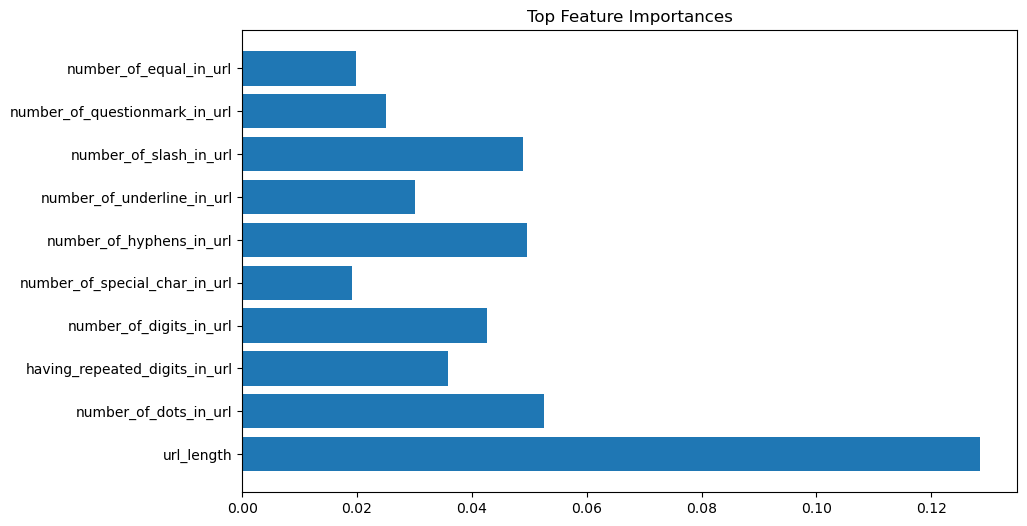

In [13]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names[:10], importance[:10])
plt.title("Top Feature Importances")
plt.show()


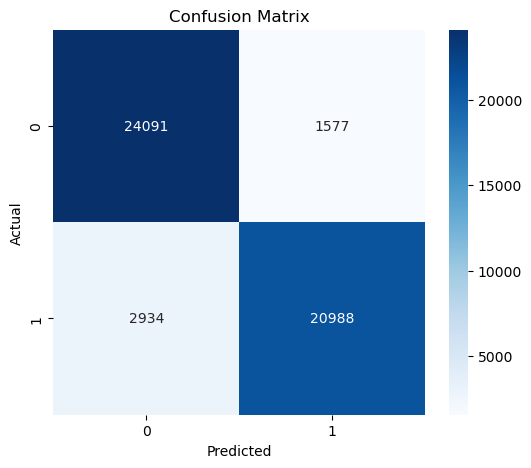

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


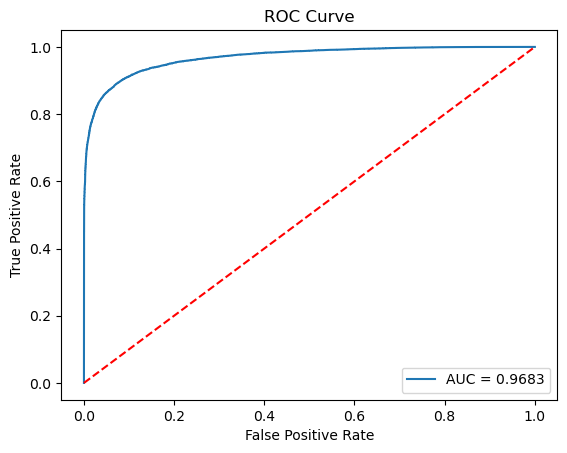

In [17]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


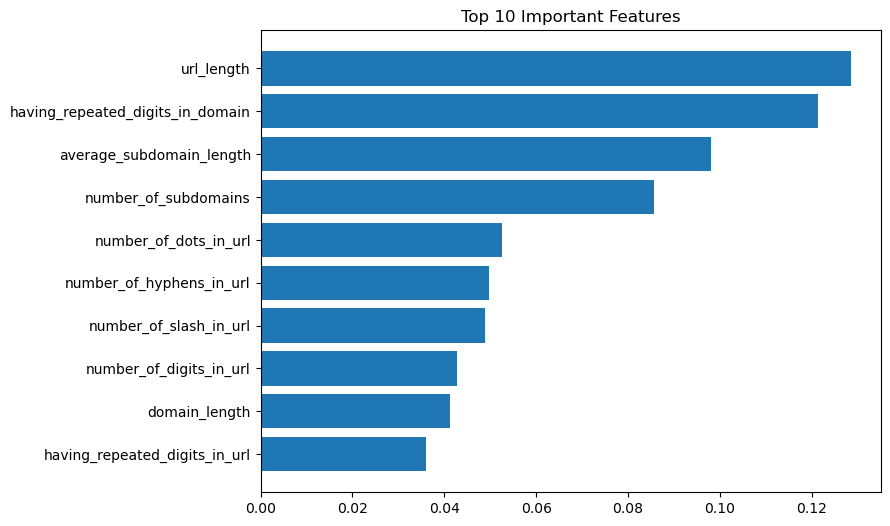

In [19]:
import pandas as pd

importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feature_importance['Feature'][:10],
         feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()


In [21]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


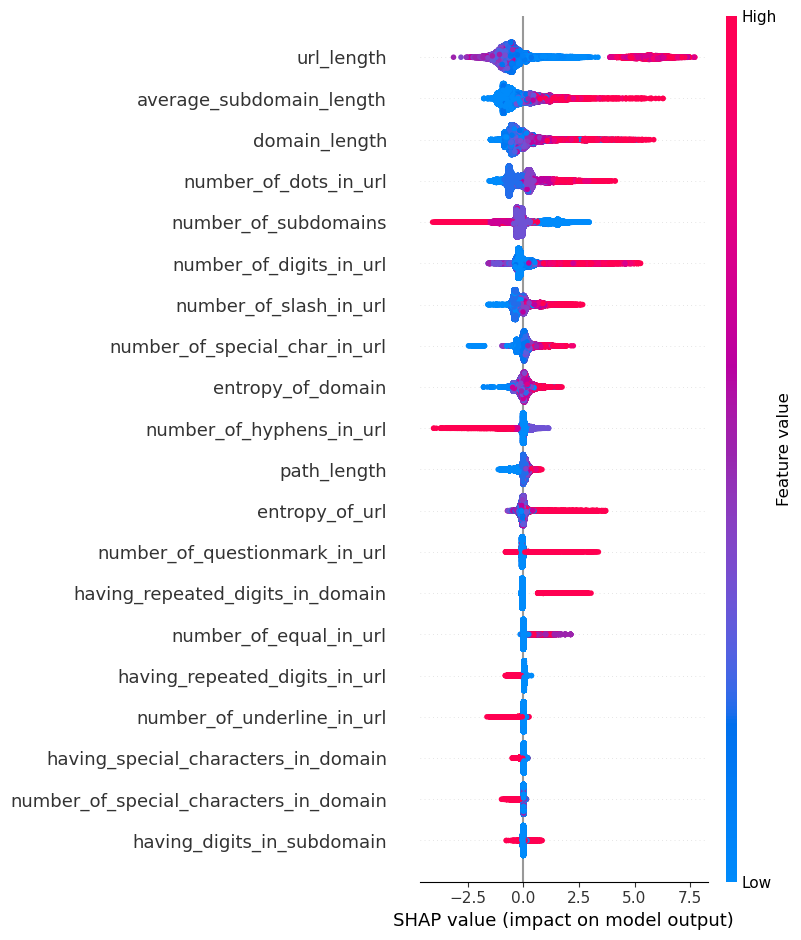

In [23]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
data = pd.read_csv(r'C:/Users/SUHANI/Downloads/Dataset.csv')

X = data.drop('Type', axis=1)
y = data['Type']

# Convert -1 to 0
y = y.replace(-1, 0)

# =========================
# 2. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 3. FEATURE SCALING
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 4. XGBOOST TUNING
# =========================
xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False)

param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

best_xgb = random_search.best_estimator_

print("Best XGBoost Params:", random_search.best_params_)

# =========================
# 5. SECOND MODEL (LOGISTIC REGRESSION)
# =========================
lr = LogisticRegression(max_iter=1000)

# =========================
# 6. ENSEMBLE MODEL
# =========================
ensemble = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lr', lr)
    ],
    voting='soft'
)

ensemble.fit(X_train_scaled, y_train)

# =========================
# 7. PREDICTIONS
# =========================
y_pred = ensemble.predict(X_test_scaled)
y_proba = ensemble.predict_proba(X_test_scaled)[:, 1]

# =========================
# 8. EVALUATION
# =========================
print("\n🔥 FINAL RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_proba))

# =========================
# 9. SAVE MODEL + SCALER
# =========================
joblib.dump(ensemble, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n✅ Model and scaler saved successfully!")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\SUHANI\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:39:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


C:\Users\SUHANI\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:39:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔥 FINAL RESULTS
Accuracy: 0.9052833232506554

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.94      0.91     25708
           1       0.93      0.87      0.90     23882

    accuracy                           0.91     49590
   macro avg       0.91      0.90      0.90     49590
weighted avg       0.91      0.91      0.91     49590


Confusion Matrix:

[[24078  1630]
 [ 3067 20815]]

ROC-AUC Score: 0.9617931094999039

✅ Model and scaler saved successfully!


In [13]:
# All imports together
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import *

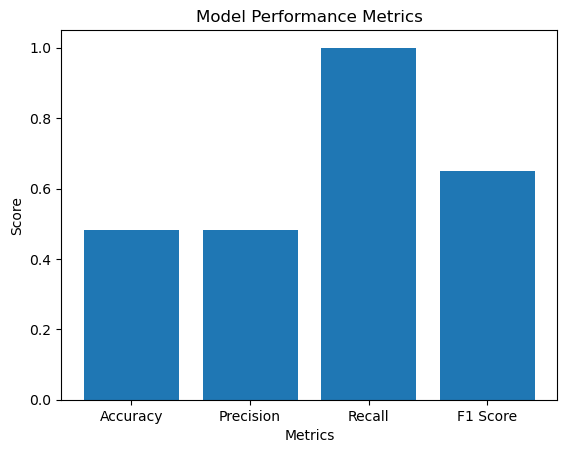

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()